In [3]:
#Solar Power Generation Forecasting and Analysis using Machine Learning
#Dataset: Solar Power Generation Dataset (Kaggle)
#Objective: Predict solar PV power output using weather and irradiation data

In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")

Environment ready!


In [6]:

from src.data_loader import load_and_merge_data

df = load_and_merge_data(
    "../data/Plant_1_Generation_Data.csv",
    "../data/Plant_1_Weather_Sensor_Data.csv"
)

df.head()

/Users/eshasingh/Documents/solar-energy-analytics/src/data_loader.py:10: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"], dayfirst=True)


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,zVJPv84UY57bAof,0.0,0.0,0.0,7116151.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,zBIq5rxdHJRwDNY,0.0,0.0,0.0,6339380.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,0.0,7007866.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,wCURE6d3bPkepu2,0.0,0.0,0.0,6782598.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [7]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

In [8]:
import os

os.makedirs("results", exist_ok=True)

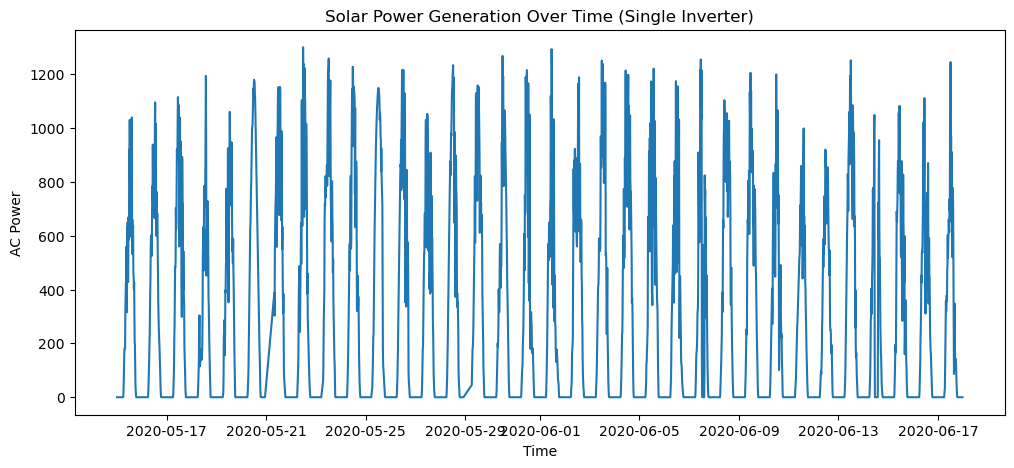

In [9]:
#Plot 1: Solar Power Generation Over Time
import matplotlib.pyplot as plt

sample = df[df["SOURCE_KEY_x"] == df["SOURCE_KEY_x"].iloc[0]]

plt.figure(figsize=(12,5))
plt.plot(sample["DATE_TIME"], sample["AC_POWER"])

plt.title("Solar Power Generation Over Time (Single Inverter)")
plt.xlabel("Time")
plt.ylabel("AC Power")
plt.savefig("results/power_generation_over_time.png")
plt.show()

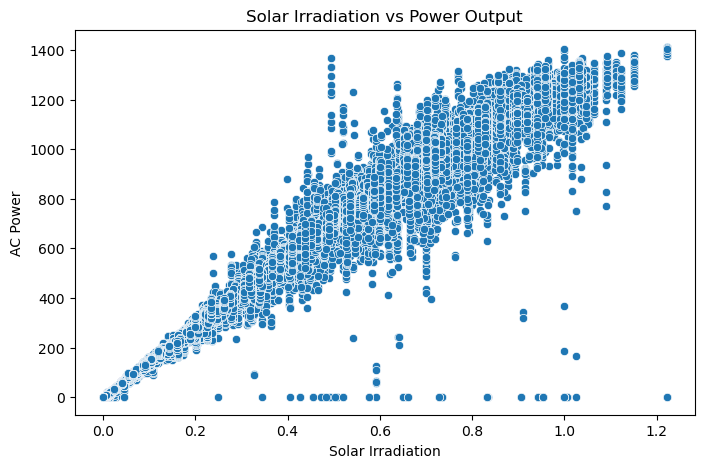

In [10]:
#Plot 2: Irradiance vs Power Output
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(x=df["IRRADIATION"], y=df["AC_POWER"])

plt.title("Solar Irradiation vs Power Output")
plt.xlabel("Solar Irradiation")
plt.ylabel("AC Power")
plt.savefig("results/irradiation_vs_power.png")
plt.show()

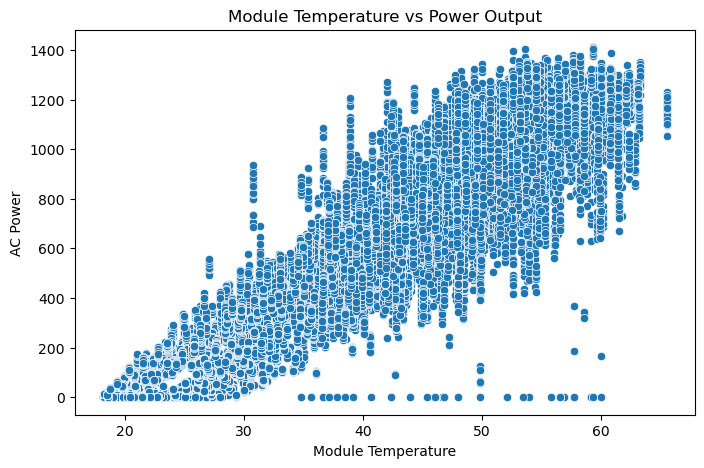

In [11]:
#Plot 3: Temperature vs Power
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["MODULE_TEMPERATURE"], y=df["AC_POWER"])

plt.title("Module Temperature vs Power Output")
plt.xlabel("Module Temperature")
plt.ylabel("AC Power")
plt.savefig("results/module_temperature_vs_power.png")
plt.show()

In [12]:
df["hour"] = df["DATE_TIME"].dt.hour

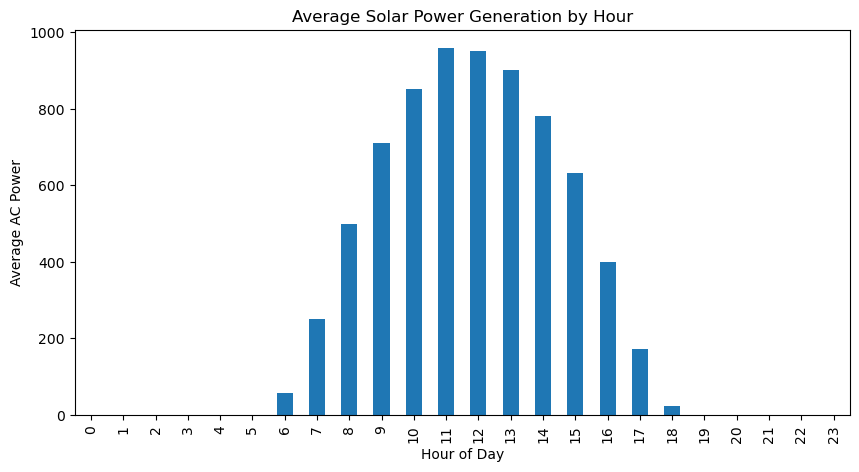

In [13]:
#Plot 4: Hourly Solar Generation
hourly = df.groupby("hour")["AC_POWER"].mean()

plt.figure(figsize=(10,5))
hourly.plot(kind="bar")

plt.title("Average Solar Power Generation by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power")
plt.savefig("results/hourly_average_power.png")
plt.show()

In [14]:
features = df[[
    "AC_POWER",
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "hour"
]]

features.head()

,AC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,hour
0,0.0,0.0,25.184316,22.857507,0
1,0.0,0.0,25.184316,22.857507,0
2,0.0,0.0,25.184316,22.857507,0
3,0.0,0.0,25.184316,22.857507,0
4,0.0,0.0,25.184316,22.857507,0


In [15]:
features.to_csv("../data/solar_cleaned_data.csv", index=False)

In [16]:
#Model training part
features = df[[
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "hour"
]]

target = df["AC_POWER"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
import joblib
import os

# create results folder if it doesn't exist
os.makedirs("../results", exist_ok=True)

# save trained model
joblib.dump(model, "../results/solar_power_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
predictions = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 16.335578481130707
R2 Score: 0.9855550864425591


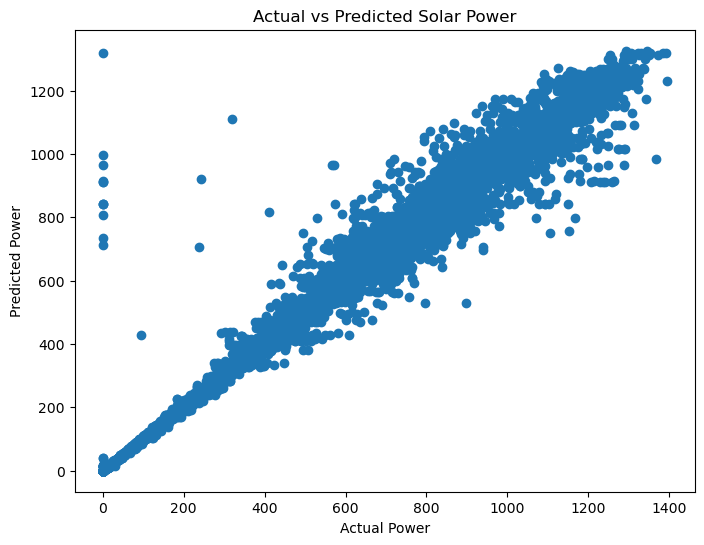

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Solar Power")
plt.savefig("results/actual_vs_predicted_power.png")
plt.show()

In [23]:
#creating time based features
df["day"] = df["DATE_TIME"].dt.day
df["month"] = df["DATE_TIME"].dt.month
df["minute"] = df["DATE_TIME"].dt.minute

In [24]:
features = df[[
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "hour",
    "day",
    "month"
]]

target = df["AC_POWER"]

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
import pandas as pd

future_data = pd.DataFrame({
    "IRRADIATION":[0.9],
    "AMBIENT_TEMPERATURE":[30],
    "MODULE_TEMPERATURE":[45],
    "hour":[12],
    "day":[15],
    "month":[6]
})

prediction = model.predict(future_data)

print("Predicted Solar Power:", prediction[0])

Predicted Solar Power: 1154.6085481802922


In [27]:
#Solar Panel Performance Monitoring / Cleaning Detection
df["PREDICTED_POWER"] = model.predict(features)
df["POWER_LOSS"] = df["PREDICTED_POWER"] - df["AC_POWER"]

In [28]:
maintenance_cases = df[
    (df["IRRADIATION"] > 0.7) & 
    (df["POWER_LOSS"] > 200)
]

maintenance_cases.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day,month,minute,PREDICTED_POWER,POWER_LOSS
4866,2020-05-17 11:00:00,4135001,pkci93gMrogZuBj,8716.125000,851.300000,2772.000000,7184422.000,4135001,HmiyD2TTLFNqkNe,31.164858,55.289362,0.812389,11,17,5,0,1059.400555,208.100555
4895,2020-05-17 11:15:00,4135001,1BY6WEcLGh8j5v7,10160.142860,991.828571,2945.142857,6274550.143,4135001,HmiyD2TTLFNqkNe,31.531130,60.208570,0.997904,11,17,5,15,1215.186973,223.358401
4929,2020-05-17 11:45:00,4135001,pkci93gMrogZuBj,7481.142857,731.814286,3612.000000,7185262.000,4135001,HmiyD2TTLFNqkNe,32.527864,61.801992,0.869909,11,17,5,45,1034.772976,302.958690
5012,2020-05-17 12:45:00,4135001,z9Y9gH1T5YWrNuG,8136.500000,795.012500,4618.125000,7025358.125,4135001,HmiyD2TTLFNqkNe,33.649188,56.556678,0.837124,12,17,5,45,1051.991552,256.979052
9160,2020-05-19 12:30:00,4135001,3PZuoBAID5Wc2HD,7412.333333,725.333333,3530.333333,7017448.333,4135001,HmiyD2TTLFNqkNe,29.644664,49.077840,0.738328,12,19,5,30,963.259630,237.926297


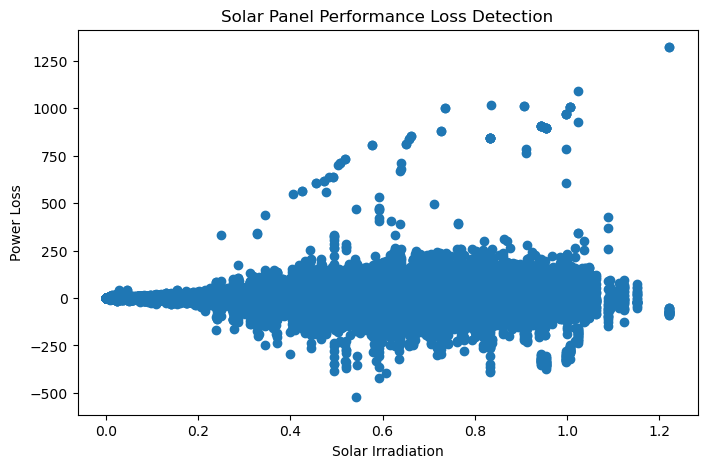

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df["IRRADIATION"], df["POWER_LOSS"])

plt.xlabel("Solar Irradiation")
plt.ylabel("Power Loss")
plt.title("Solar Panel Performance Loss Detection")

plt.show()

In [30]:
df["EFFICIENCY_RATIO"] = df["AC_POWER"] / df["PREDICTED_POWER"]

In [31]:
from src.cleaning_detection import detect_cleaning

df = detect_cleaning(df)

In [32]:
df[df["CLEANING_REQUIRED"] == True].head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,...,IRRADIATION,hour,day,month,minute,PREDICTED_POWER,POWER_LOSS,EFFICIENCY_RATIO,CLEANING_REQUIRED,CLEANING_STATUS
782,2020-05-15 09:00:00,4135001,zVJPv84UY57bAof,5085.857143,498.471429,653.285714,7116804.286,4135001,HmiyD2TTLFNqkNe,27.620970,...,0.623153,9,15,5,0,733.483382,235.011953,0.679595,True,Cleaning Required
869,2020-05-15 10:00:00,4135001,bvBOhCH3iADSZry,5785.125000,567.062500,1173.250000,6317976.250,4135001,HmiyD2TTLFNqkNe,28.632192,...,0.670675,10,15,5,0,797.638977,230.576477,0.710926,True,Cleaning Required
872,2020-05-15 10:00:00,4135001,1BY6WEcLGh8j5v7,6008.375000,588.775000,1161.250000,6260720.250,4135001,HmiyD2TTLFNqkNe,28.632192,...,0.670675,10,15,5,0,797.638977,208.863977,0.738147,True,Cleaning Required
4929,2020-05-17 11:45:00,4135001,pkci93gMrogZuBj,7481.142857,731.814286,3612.000000,7185262.000,4135001,HmiyD2TTLFNqkNe,32.527864,...,0.869909,11,17,5,45,1034.772976,302.958690,0.707222,True,Cleaning Required
4946,2020-05-17 12:00:00,4135001,z9Y9gH1T5YWrNuG,5933.714286,581.414286,3927.571429,7024667.571,4135001,HmiyD2TTLFNqkNe,32.495968,...,0.635451,12,17,5,0,796.131803,214.717517,0.730299,True,Cleaning Required


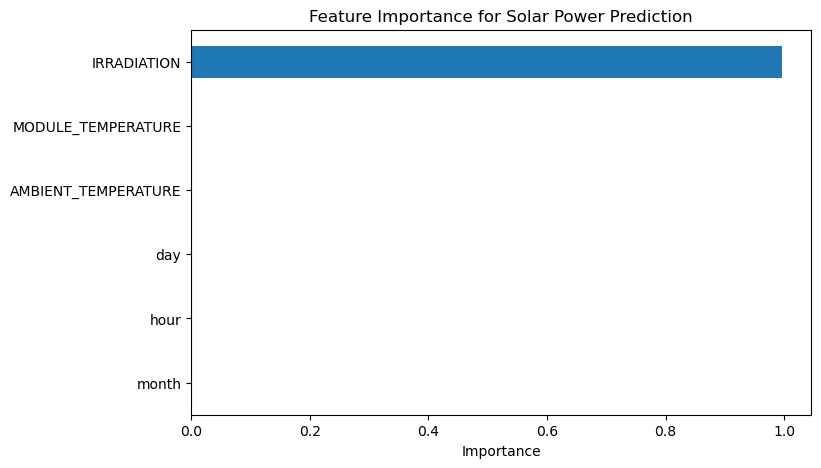

In [33]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance for Solar Power Prediction")
plt.xlabel("Importance")
plt.savefig("results/feature_importance.png")
plt.show()

In [34]:
df.to_csv("results/solar_prediction_results.csv", index=False)